# Doğal Dil İşleme ve Tekrarlayan Sinir Ağları (RNN) ile Duygu Analizi

In [ ]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=1jtSySSXVk2FqR6r5IeoZUvcaAYNBMujK', 'IMDB_Dataset.csv', quiet = False)

Downloading...
From: https://drive.google.com/uc?id=1jtSySSXVk2FqR6r5IeoZUvcaAYNBMujK
To: /content/IMDB_Dataset.csv
100%|██████████| 66.2M/66.2M [00:01<00:00, 50.9MB/s]


'IMDB_Dataset.csv'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

df = pd.read_csv("IMDB_Dataset.csv")
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
y = (df["sentiment"] == "positive").astype(int).values

print(y[:10])
print("Toplam örnek sayısı : ", len(y))

[1 1 1 0 1 1 1 0 0 1]
Toplam örnek sayısı :  50000


In [ ]:
tokenizer = Tokenizer(num_words = 10000)
tokenizer.fit_on_texts(df["review"])

diziler = tokenizer.texts_to_sequences(df["review"])
X = pad_sequences(diziler, maxlen = 200)

print("X boyutu : ", X.shape)
print(X[0])

X boyutu :  (50000, 200)
[  12    6    1  358    5    1 6813 2538 1064    9 2711 1421   20  538
   32 4636 2468    4    1 1208  117   29    1 7017   25 2970    2  391
   34    6   21  299   20    1 4910 7364  538    6  344    5  106 8161
 5050 7889 2453    2   51   34  327 9106 7365    2 8697   23  110  225
  243    7    7   10   58  131    1  280 1324    4    1  119    6  693
    5    1  192   12    9  269  117   79  276  589 3024  834  180 1320
 4161   15 2523 1243  834 1443  834  887 3184  149  954  183    1   86
  398   10  123  210 3241   68   14   34 1637    9   13 2239   10  413
  131   10   13 1592   15    9   18   14   10  287   51   10 1417    3
 1280   15 3184    2  189    5    1  299 2046    4 2150  570   21   39
  570   18 7658 7154 5010   26 2983   41   15    3 6904  504   20  642
    2   76  243   16    9   69 7598  651  710 6904  109  662   82 1208
  693    5   65  574    4  920 2021   38 1208  559  147 3184   22  200
  426 3819   16   48    6 3314  805 1603   43   22  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Egitim seti : ", X_train.shape)
print("Test seti : ", X_test.shape)

Egitim seti :  (40000, 200)
Test seti :  (10000, 200)


In [ ]:
model = Sequential([
    Embedding(input_dim = 10000, output_dim = 32),
    SimpleRNN(32),
    Dense(1, activation = "sigmoid"),
])

model.compile(
    loss="binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6539 - loss: 0.6075 - val_accuracy: 0.8021 - val_loss: 0.4461
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8298 - loss: 0.3915 - val_accuracy: 0.8399 - val_loss: 0.3704
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8836 - loss: 0.2905 - val_accuracy: 0.8526 - val_loss: 0.3526
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9139 - loss: 0.2231 - val_accuracy: 0.8489 - val_loss: 0.3862
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9393 - loss: 0.1683 - val_accuracy: 0.8470 - val_loss: 0.4512


In [ ]:
kayip, dogruluk = model.evaluate(X_test, y_test)
print("Test kaybı : ", kayip)
print("Test doğruluğu : ", dogruluk)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8499 - loss: 0.4432
Test kaybı :  0.44318491220474243
Test doğruluğu :  0.8499000072479248


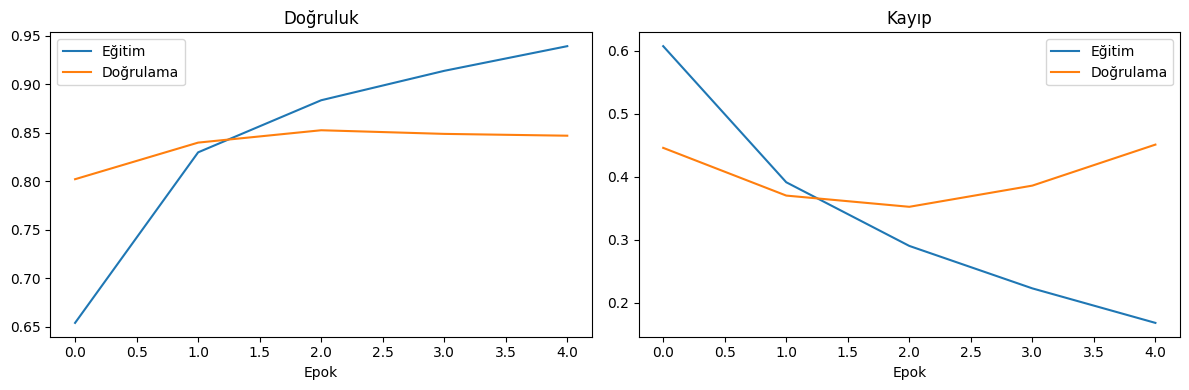

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Eğitim")
plt.plot(history.history["val_accuracy"], label = "Doğrulama")
plt.title("Doğruluk")
plt.xlabel("Epok")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Eğitim")
plt.plot(history.history["val_loss"], label="Doğrulama")
plt.title("Kayıp")
plt.xlabel("Epok")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def yorum_tahmin_et(metin):
    dizi = tokenizer.texts_to_sequences([metin])
    dizi_pad = pad_sequences(dizi, maxlen = 200)
    tahmin = model.predict(dizi_pad)[0][0]
    sonuc = "Olumlu" if tahmin > 0.5 else "Olumsuz"
    print(f"Yorum : {metin}")
    print(f"Tahmin : {sonuc} (olasılık : {tahmin:.4f})")

yorum_tahmin_et("This movie was absolutely fantastic, I loved every minute of it!")
yorum_tahmin_et("Terrible movie, waste of time, I hated it.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Yorum : This movie was absolutely fantastic, I loved every minute of it!
Tahmin : Olumlu (olasılık : 0.8418)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Yorum : Terrible movie, waste of time, I hated it.
Tahmin : Olumsuz (olasılık : 0.0056)


#### Modelin 3. epoktan sonra ezberlemeye başladığı gözlemlenmiştir.